# Pattern Recognition and Machine Learning (EE602L)
## Lab 4: Multiclass Logistic Regression and Support Vector Machines

**Roll No:** EC24BT033

<style>pre, code { white-space: pre-wrap !important; word-break: break-word; }</style>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_breast_cancer, make_blobs, make_classification
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

## Question 1: Multiclass Logistic Regression via Softmax

### (a) Data preparation

The Wine dataset: 178 samples, 13 numeric features (chemical measurements of wines), 3 classes (three grape cultivars). With 3 classes the binary sigmoid no longer suffices; softmax generalizes it by producing one probability per class that sum to 1.

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print("Shape:", df.shape)
print("\nClass balance:")
for k in range(3):
    n_k = int((df["target"] == k).sum())
    print(f"  class {k} ({wine.target_names[k]}): {n_k} samples ({n_k/len(df):.1%})")

Shape: (178, 14)

Class balance:
  class 0 (class_0): 59 samples (33.1%)
  class 1 (class_1): 71 samples (39.9%)
  class 2 (class_2): 48 samples (27.0%)


In [3]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


**Stratified split.** A plain shuffled split can distort class proportions in a dataset this small (a 15% slice is only ~27 rows). Stratified sampling splits each class separately in the 70:15:15 ratio and then combines them, so every split preserves the original class mix. Implemented from scratch with seed 42.

In [4]:
def stratified_split(df, label_col, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Split each class separately so all three sets keep the class proportions."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"
    rng = np.random.default_rng(seed)

    train_parts = []
    val_parts = []
    test_parts = []
    for cls in sorted(df[label_col].unique()):
        cls_idx = df.index[df[label_col] == cls].to_numpy()
        cls_idx = cls_idx[rng.permutation(len(cls_idx))]     # shuffle within the class
        n_train = int(train_ratio * len(cls_idx))
        n_val = int(val_ratio * len(cls_idx))
        train_parts.append(cls_idx[:n_train])
        val_parts.append(cls_idx[n_train:n_train + n_val])
        test_parts.append(cls_idx[n_train + n_val:])

    train_idx = np.concatenate(train_parts)
    val_idx = np.concatenate(val_parts)
    test_idx = np.concatenate(test_parts)
    return df.loc[train_idx], df.loc[val_idx], df.loc[test_idx]


train_df, val_df, test_df = stratified_split(df, "target")
print(f"train: {len(train_df)} rows ({len(train_df)/len(df):.1%})")
print(f"val:   {len(val_df)} rows ({len(val_df)/len(df):.1%})")
print(f"test:  {len(test_df)} rows ({len(test_df)/len(df):.1%})")

tr = set(train_df.index)
va = set(val_df.index)
te = set(test_df.index)
print("\noverlaps:", len(tr & va), len(tr & te), len(va & te))
assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE: splits overlap!"
assert len(tr | va | te) == len(df), "rows lost or duplicated"
print("verified: splits are disjoint and cover all", len(df), "rows")

print("\nclass proportions per split (stratification check):")
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    props = part["target"].value_counts(normalize=True).sort_index().round(3).tolist()
    print(f"  {name}: {props}")

train: 123 rows (69.1%)
val:   25 rows (14.0%)
test:  30 rows (16.9%)

overlaps: 0 0 0
verified: splits are disjoint and cover all 178 rows

class proportions per split (stratification check):
  train: [0.333, 0.398, 0.268]
  val: [0.32, 0.4, 0.28]
  test: [0.333, 0.4, 0.267]


In [5]:
feature_cols = [str(c) for c in wine.feature_names]

# Standardize with TRAIN statistics only
train_means = train_df[feature_cols].mean()
train_stds = train_df[feature_cols].std()

train_p = train_df.copy()
val_p = val_df.copy()
test_p = test_df.copy()
for part in [train_p, val_p, test_p]:
    part[feature_cols] = (part[feature_cols] - train_means) / train_stds

def make_X_y(part):
    X = part[feature_cols].to_numpy(dtype=float)
    X = np.hstack([np.ones((len(X), 1)), X])          # intercept column
    y = part["target"].to_numpy(dtype=int)
    return X, y

X_train, y_train = make_X_y(train_p)
X_val, y_val = make_X_y(val_p)
X_test, y_test = make_X_y(test_p)

K = 3
# One-hot targets for training; integer labels kept for evaluation
Y_train = np.eye(K)[y_train]
print("X_train:", X_train.shape, " Y_train (one-hot):", Y_train.shape)
print("example: label", y_train[0], "-> one-hot", Y_train[0])

X_train: (123, 14)  Y_train (one-hot): (123, 3)
example: label 0 -> one-hot [1. 0. 0.]


### (b) Model implementation

Softmax turns a vector of K class scores into K probabilities: P(y = k | x) = e^(z_k) / sum_j e^(z_j). We subtract the row maximum before exponentiating, which changes nothing mathematically (it cancels in the ratio) but prevents e^z from overflowing. The multiclass cross-entropy is J = -(1/n) sum_i sum_k Y_ik log(P_ik), and its gradient has the same clean shape as the binary case: (1/n) X^T (P - Y).

In [6]:
def softmax(Z):
    """Row-wise softmax with the max-subtraction trick for numerical stability."""
    Z_shifted = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z_shifted)
    return expZ / expZ.sum(axis=1, keepdims=True)

def predict_proba_softmax(X, Theta):
    return softmax(X @ Theta)

def cross_entropy(Y_onehot, P):
    """Multiclass cross-entropy. Clip only inside the log, for stability."""
    P = np.clip(P, 1e-15, 1 - 1e-15)
    return -np.mean(np.sum(Y_onehot * np.log(P), axis=1))

def gradient_descent_softmax(X, Y_onehot, lr, n_iters):
    """Batch gradient descent on the multiclass cross-entropy."""
    n = len(Y_onehot)
    Theta = np.zeros((X.shape[1], Y_onehot.shape[1]))   # (d+1, K)
    history = []
    for it in range(n_iters):
        P = predict_proba_softmax(X, Theta)
        history.append(cross_entropy(Y_onehot, P))
        grad = (1 / n) * (X.T @ (P - Y_onehot))
        Theta = Theta - lr * grad
    return Theta, history


Y_val_onehot = np.eye(K)[y_val]
learning_rates = [0.01, 0.1, 1.0]
n_iters = 3000

runs = {}
for lr in learning_rates:
    Theta_lr, hist = gradient_descent_softmax(X_train, Y_train, lr, n_iters)
    val_ce = cross_entropy(Y_val_onehot, predict_proba_softmax(X_val, Theta_lr))
    runs[lr] = {"Theta": Theta_lr, "history": hist, "val_ce": val_ce}
    print(f"lr = {lr:5}: final train cross-entropy = {hist[-1]:.4f},  validation cross-entropy = {val_ce:.4f}")

best_lr = min(runs, key=lambda lr: runs[lr]["val_ce"])
Theta_best = runs[best_lr]["Theta"]
print("\nbest learning rate by validation cross-entropy:", best_lr)

lr =  0.01: final train cross-entropy = 0.0514,  validation cross-entropy = 0.0604
lr =   0.1: final train cross-entropy = 0.0098,  validation cross-entropy = 0.0566
lr =   1.0: final train cross-entropy = 0.0013,  validation cross-entropy = 0.0854

best learning rate by validation cross-entropy: 0.1


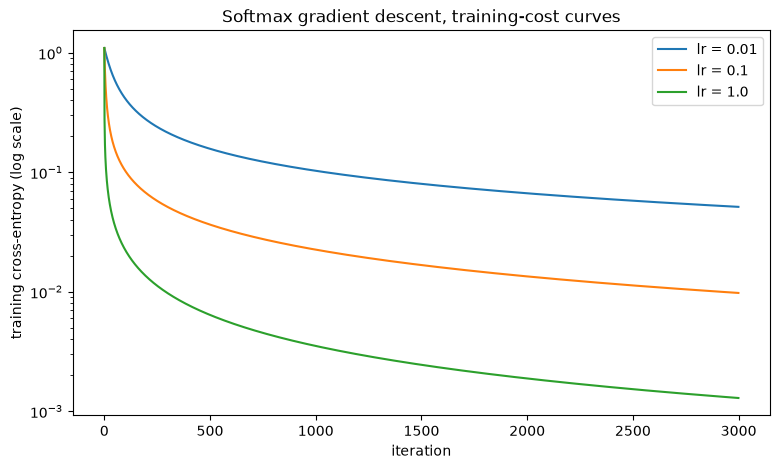

In [7]:
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    plt.plot(runs[lr]["history"], label=f"lr = {lr}")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("training cross-entropy (log scale)")
plt.title("Softmax gradient descent, training-cost curves")
plt.legend()
plt.show()

**Numerical check: softmax with K = 2 reduces to the sigmoid.** With two classes, P(class 1) = e^(z1) / (e^(z0) + e^(z1)) = 1 / (1 + e^(-(z1 - z0))) = sigmoid(z1 - z0). So a 2-column softmax where the class-0 column is fixed at zero (theta_0 = 0) must equal sigmoid applied to the class-1 scores. We verify this numerically on random scores.

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

rng = np.random.default_rng(42)
z = rng.normal(size=1000) * 5                    # random class-1 scores

Z2 = np.column_stack([np.zeros_like(z), z])      # class-0 score fixed at 0
p_softmax = softmax(Z2)[:, 1]                    # softmax probability of class 1
p_sigmoid = sigmoid(z)                           # binary sigmoid of the same scores

max_diff = np.max(np.abs(p_softmax - p_sigmoid))
print("max |softmax(K=2) - sigmoid| over 1000 random scores:", max_diff)
assert max_diff < 1e-12
print("verified: softmax with K = 2 and theta_0 = 0 is exactly the binary sigmoid")

max |softmax(K=2) - sigmoid| over 1000 random scores: 1.1102230246251565e-16
verified: softmax with K = 2 and theta_0 = 0 is exactly the binary sigmoid


### (c) Evaluation

Each test sample is assigned the class with the highest predicted probability (argmax). Confusion matrix, accuracy, macro precision/recall/F1 and multiclass log-loss are all computed manually; macro averaging computes each metric per class and then averages, treating all classes equally regardless of size.

In [9]:
def confusion_matrix_manual(y_true, y_pred, K):
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def macro_metrics(cm):
    """Per-class precision/recall/F1 from the confusion matrix, macro-averaged."""
    K = cm.shape[0]
    precisions = []
    recalls = []
    f1s = []
    for k in range(K):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

def multiclass_log_loss(y_true, P):
    P = np.clip(P, 1e-15, 1 - 1e-15)
    return -np.mean(np.log(P[np.arange(len(y_true)), y_true]))


P_test = predict_proba_softmax(X_test, Theta_best)
y_pred = np.argmax(P_test, axis=1)

cm = confusion_matrix_manual(y_test, y_pred, K)
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=wine.target_names, columns=wine.target_names).to_string())

acc = np.mean(y_pred == y_test)
prec, rec, f1 = macro_metrics(cm)
ll = multiclass_log_loss(y_test, P_test)
print(f"\naccuracy:        {acc:.4f}")
print(f"macro precision: {prec:.4f}")
print(f"macro recall:    {rec:.4f}")
print(f"macro F1:        {f1:.4f}")
print(f"log-loss:        {ll:.4f}")

Confusion matrix (rows = true, cols = predicted):
         class_0  class_1  class_2
class_0       10        0        0
class_1        0       12        0
class_2        0        0        8

accuracy:        1.0000
macro precision: 1.0000
macro recall:    1.0000
macro F1:        1.0000
log-loss:        0.0044


In [10]:
# Comparison against sklearn's LogisticRegression (features without our ones column)
sk_model = LogisticRegression(max_iter=5000)
sk_model.fit(X_train[:, 1:], y_train)

P_sk = sk_model.predict_proba(X_test[:, 1:])
y_pred_sk = sk_model.predict(X_test[:, 1:])

cm_sk = confusion_matrix_manual(y_test, y_pred_sk, K)
prec_sk, rec_sk, f1_sk = macro_metrics(cm_sk)

comparison = pd.DataFrame({
    "from-scratch softmax": {"accuracy": acc, "macro precision": prec, "macro recall": rec,
                             "macro F1": f1, "log-loss": ll},
    "sklearn LogisticRegression": {"accuracy": np.mean(y_pred_sk == y_test), "macro precision": prec_sk,
                                   "macro recall": rec_sk, "macro F1": f1_sk,
                                   "log-loss": multiclass_log_loss(y_test, P_sk)},
})
print(comparison.round(4).to_string())

                 from-scratch softmax  sklearn LogisticRegression
accuracy                       1.0000                       1.000
macro precision                1.0000                       1.000
macro recall                   1.0000                       1.000
macro F1                       1.0000                       1.000
log-loss                       0.0044                       0.026


**Discussion:** both models classify the test set perfectly; the Wine classes are well separated after standardization, so a linear multiclass model has an easy job. The only difference is in log-loss, and it runs the way regularization predicts: sklearn's LogisticRegression applies a default L2 penalty (C = 1), which tempers its probabilities and leaves a slightly higher log-loss (0.026), while our from-scratch model is unpenalized, so its probabilities are more confident and, since every prediction is correct, its log-loss is lower (0.004). On a harder or noisier test set that extra confidence would be a liability, not an advantage (Lab 3's lesson). The agreement in classifications validates the from-scratch implementation.

## Question 2: Support Vector Machines

### (a) Geometric intuition on synthetic 2D data

A linear SVM chooses the separating line that maximizes the margin, the distance to the closest points of each class. Those closest points are the support vectors: they alone determine the boundary, every other point could move (a little) without changing anything. The dashed lines below are the margin boundaries (decision function = +1 and -1).

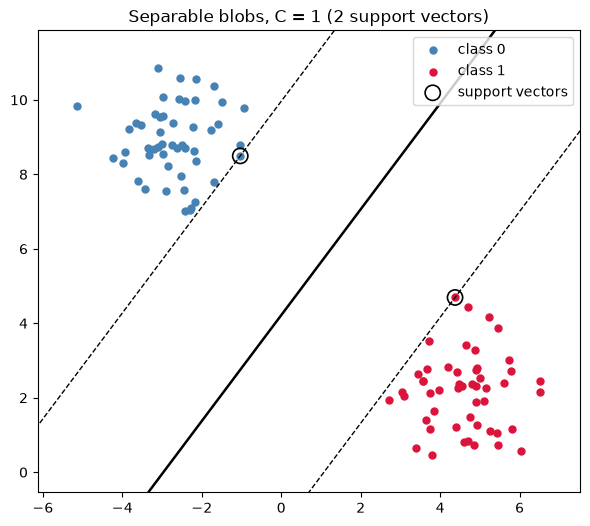

In [11]:
def plot_svm(ax, model, X, y, title):
    """Scatter the data, draw decision boundary + margins, circle the support vectors."""
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="steelblue", s=25, label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="crimson", s=25, label="class 1")

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k",
               linestyles=["--", "-", "--"], linewidths=[1, 1.8, 1])
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=120, facecolors="none", edgecolors="black", linewidths=1.2, label="support vectors")
    ax.set_title(title)


# Well-separated blobs
X_sep, y_sep = make_blobs(n_samples=100, centers=2, cluster_std=1.0, random_state=42)
svm_sep = SVC(kernel="linear", C=1.0)
svm_sep.fit(X_sep, y_sep)

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(ax, svm_sep, X_sep, y_sep,
         f"Separable blobs, C = 1 ({len(svm_sep.support_)} support vectors)")
ax.legend()
plt.show()

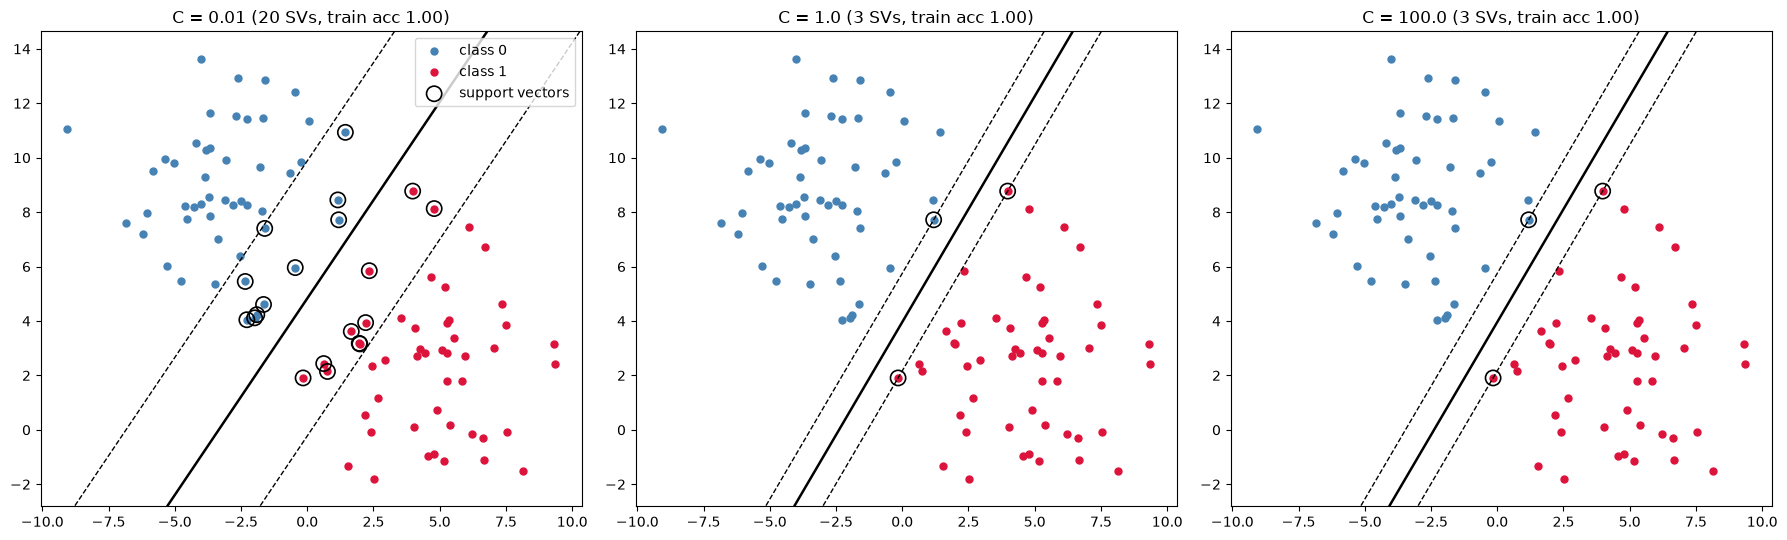

In [12]:
# Overlapping blobs, three values of C
X_ov, y_ov = make_blobs(n_samples=100, centers=2, cluster_std=2.5, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, C in zip(axes, [0.01, 1.0, 100.0]):
    svm_c = SVC(kernel="linear", C=C)
    svm_c.fit(X_ov, y_ov)
    train_acc = svm_c.score(X_ov, y_ov)
    plot_svm(ax, svm_c, X_ov, y_ov,
             f"C = {C} ({len(svm_c.support_)} SVs, train acc {train_acc:.2f})")
axes[0].legend()
plt.tight_layout()
plt.show()

**Effect of C:** C is the price of a margin violation. Small C makes violations cheap, so the SVM buys a **wide** margin and tolerates points inside it or misclassified: many support vectors, a boundary governed by the bulk of the data. Large C makes violations expensive, so the margin **narrows** to avoid them: fewer support vectors, and the boundary bends toward individual borderline points. On separable data the boundary itself barely moves; what changes is the margin width and how many points participate as support vectors. C plays the inverse role of alpha in Labs 2-3: large C = weak regularization.

### (b) Effect of regularization on overlapping data

In [13]:
# Overlapping 2D dataset and an 80:20 split from scratch, seed 42
X2, y2 = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                             n_clusters_per_class=1, class_sep=0.8, flip_y=0.08, random_state=42)

rng = np.random.default_rng(42)
perm = rng.permutation(len(X2))
n_train2 = int(0.8 * len(X2))
train_idx2 = perm[:n_train2]
val_idx2 = perm[n_train2:]
X2_train, y2_train = X2[train_idx2], y2[train_idx2]
X2_val, y2_val = X2[val_idx2], y2[val_idx2]
print(f"train {len(X2_train)} rows, val {len(X2_val)} rows, overlap:",
      len(set(train_idx2) & set(val_idx2)))

train 240 rows, val 60 rows, overlap: 0


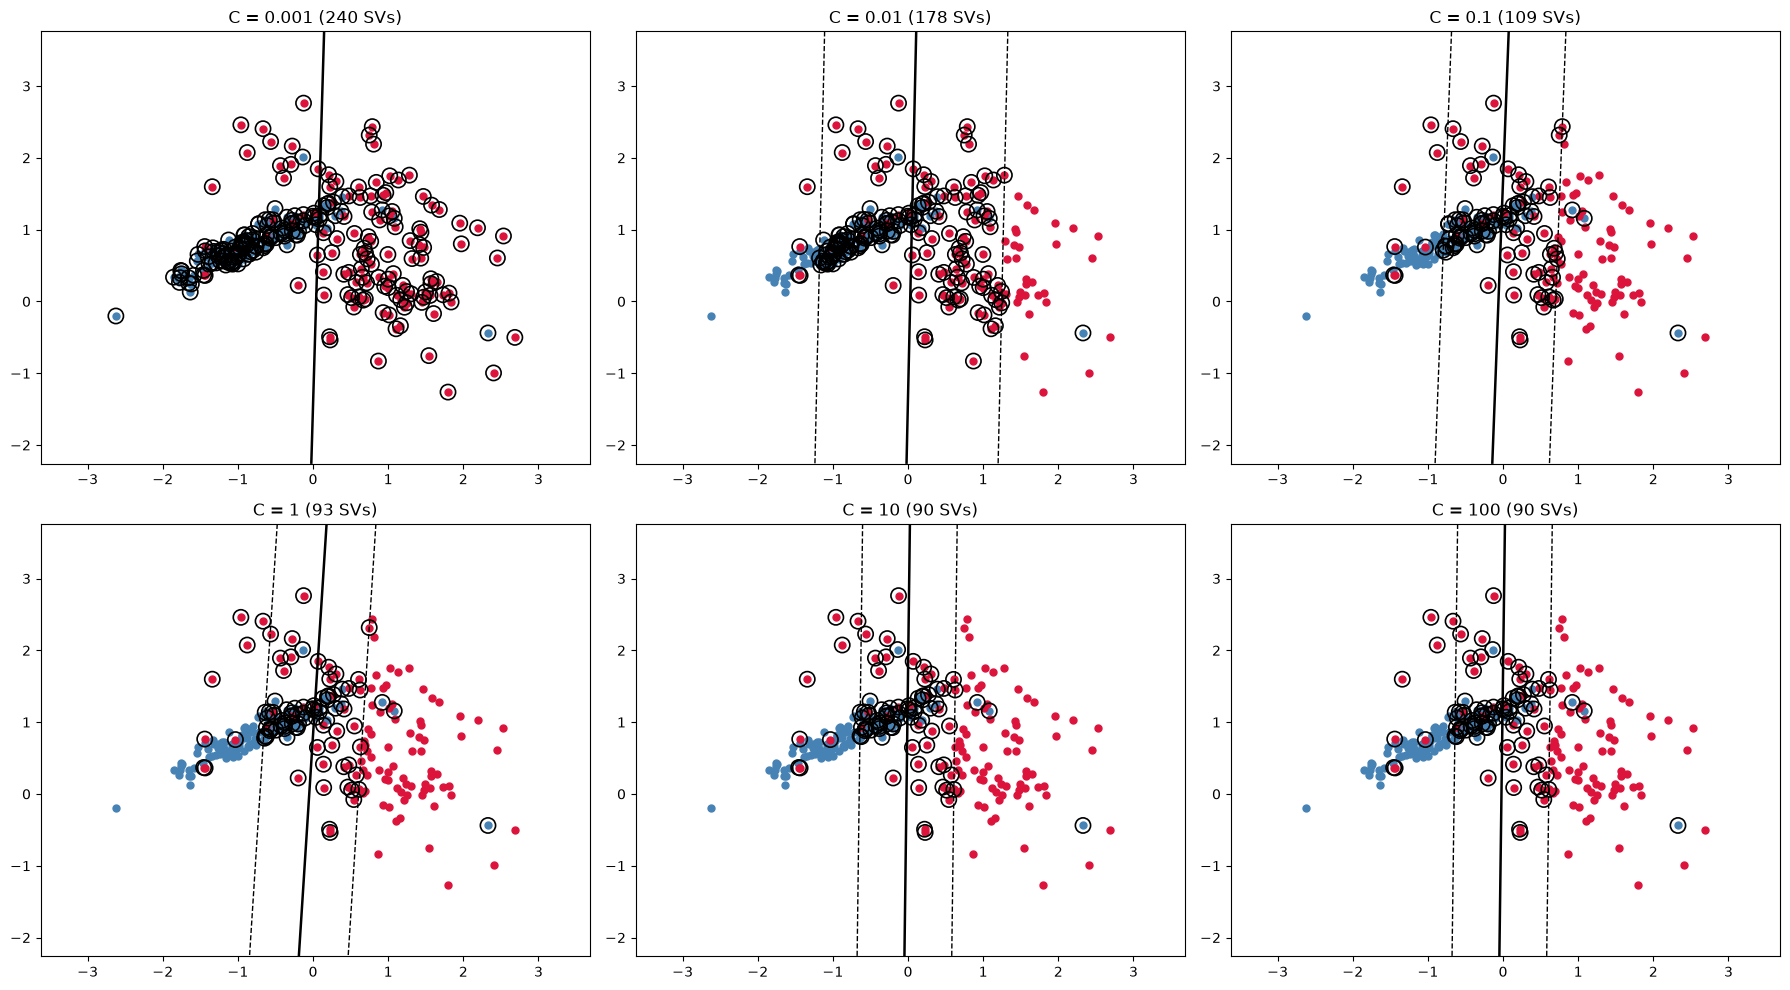

      C  support vectors  train accuracy  val accuracy
  0.001              240        0.854167      0.800000
  0.010              178        0.862500      0.800000
  0.100              109        0.854167      0.833333
  1.000               93        0.858333      0.816667
 10.000               90        0.854167      0.816667
100.000               90        0.854167      0.816667


In [14]:
C_values_2d = [0.001, 0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
rows = []
for ax, C in zip(axes.ravel(), C_values_2d):
    svm_c = SVC(kernel="linear", C=C)
    svm_c.fit(X2_train, y2_train)
    train_acc = svm_c.score(X2_train, y2_train)
    val_acc = svm_c.score(X2_val, y2_val)
    rows.append({"C": C, "support vectors": len(svm_c.support_),
                 "train accuracy": train_acc, "val accuracy": val_acc})
    plot_svm(ax, svm_c, X2_train, y2_train,
             f"C = {C} ({len(svm_c.support_)} SVs)")
plt.tight_layout()
plt.show()

results_2d = pd.DataFrame(rows)
print(results_2d.to_string(index=False))

**Discussion:** as C grows the margin narrows and the support-vector count drops: at C = 0.001 nearly every point is a support vector (the margin is so wide it swallows the dataset), while at C = 100 only the points near the boundary matter. Training accuracy creeps up with C (the boundary works harder to classify borderline points), but validation accuracy is flat or slightly better at moderate C: with genuinely overlapping classes the extra effort just chases noise (the flipped labels), which is overfitting in miniature. The trade-off: small C = wide margin, more bias, more stability; large C = narrow margin, less bias, more variance.

### (c) Full evaluation on a real dataset

Breast Cancer Wisconsin again (as in Lab 3, we relabel so that the positive class 1 = malignant, making recall mean "cancers caught"). Stratified 70:15:15 split with seed 42, standardization with train statistics, then a C sweep for a linear SVM selected on validation accuracy.

In [15]:
cancer = load_breast_cancer()
cdf = pd.DataFrame(cancer.data, columns=[str(c) for c in cancer.feature_names])
cdf["target"] = 1 - cancer.target          # 1 = malignant

ctrain_df, cval_df, ctest_df = stratified_split(cdf, "target")
print(f"train {len(ctrain_df)}, val {len(cval_df)}, test {len(ctest_df)}")
print("malignant fraction per split:",
      round(ctrain_df['target'].mean(), 3), round(cval_df['target'].mean(), 3), round(ctest_df['target'].mean(), 3))

cancer_features = [str(c) for c in cancer.feature_names]
c_means = ctrain_df[cancer_features].mean()
c_stds = ctrain_df[cancer_features].std()
for part in [ctrain_df, cval_df, ctest_df]:
    part[cancer_features] = (part[cancer_features] - c_means) / c_stds

Xc_train = ctrain_df[cancer_features].to_numpy()
yc_train = ctrain_df["target"].to_numpy()
Xc_val = cval_df[cancer_features].to_numpy()
yc_val = cval_df["target"].to_numpy()
Xc_test = ctest_df[cancer_features].to_numpy()
yc_test = ctest_df["target"].to_numpy()

train 397, val 84, test 88
malignant fraction per split: 0.373 0.369 0.375


In [16]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

svm_models = {}
rows = []
for C in C_values:
    m = SVC(kernel="linear", C=C)
    m.fit(Xc_train, yc_train)
    svm_models[C] = m
    rows.append({"C": C,
                 "support vectors": len(m.support_),
                 "train accuracy": m.score(Xc_train, yc_train),
                 "val accuracy": m.score(Xc_val, yc_val),
                 "test accuracy": m.score(Xc_test, yc_test)})

sweep_table = pd.DataFrame(rows)
print(sweep_table.round(4).to_string(index=False))

best_C = max(svm_models, key=lambda C: svm_models[C].score(Xc_val, yc_val))
best_svm = svm_models[best_C]
print(f"\nselected C = {best_C} (by validation accuracy), support vectors: {len(best_svm.support_)}")

      C  support vectors  train accuracy  val accuracy  test accuracy
  0.001              191          0.9471        0.9048         0.9205
  0.010               91          0.9698        0.9762         0.9545
  0.100               48          0.9849        0.9762         0.9659
  1.000               33          0.9849        0.9643         0.9886
 10.000               27          0.9899        0.9524         0.9545
100.000               25          0.9975        0.9286         0.9659

selected C = 0.01 (by validation accuracy), support vectors: 91


In [17]:
# Test-set evaluation of the selected model (binary metrics computed manually, as in Lab 3)
def binary_metrics(y, y_pred):
    tp = int(np.sum((y_pred == 1) & (y == 1)))
    fp = int(np.sum((y_pred == 1) & (y == 0)))
    fn = int(np.sum((y_pred == 0) & (y == 1)))
    tn = int(np.sum((y_pred == 0) & (y == 0)))
    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "F1": f1}


y_pred_test = best_svm.predict(Xc_test)
scores_test = best_svm.decision_function(Xc_test)    # signed distances to the boundary

metrics = binary_metrics(yc_test, y_pred_test)
metrics["ROC-AUC"] = roc_auc_score(yc_test, scores_test)

print(f"Test metrics for the selected linear SVM (C = {best_C}):")
for name, value in metrics.items():
    print(f"  {name:10s} {value:.4f}")

Test metrics for the selected linear SVM (C = 0.01):
  accuracy   0.9545
  precision  1.0000
  recall     0.8788
  F1         0.9355
  ROC-AUC    0.9994


**Discussion:** the C sweep shows the same story as the 2D pictures, now in 30 dimensions. (C = 0.01 and C = 0.1 tie on validation accuracy; the selection keeps the more regularized C = 0.01, the standard tie-break since the simpler model is the safer generalization bet.) Small C leans on hundreds of support vectors and a wide margin; as C grows the model relies on ever fewer boundary cases, training accuracy rises, and validation accuracy peaks at a moderate C before flattening: past that point extra sharpness buys nothing because the remaining errors are genuinely ambiguous tumors. The selected model generalizes excellently (test metrics above, ROC-AUC computed from the decision-function scores, i.e. the signed margin distances, which rank tumors without needing probabilities). Regularization-wise, C in an SVM is the inverse of alpha in Labs 2-3: small C = strong regularization = simpler, wider-margin boundary that generalizes; large C = weak regularization = a boundary contorted around individual training points. On this dataset, as in Lab 3, moderate regularization matches or beats the extremes while using a more stable model.